In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,hamming_loss


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout,Bidirectional,GRU,SimpleRNN
from tensorflow.keras.utils import to_categorical

nltk.download('stopwords',quiet=True)
nltk.download('wordnet',quiet=True)
nltk.download('punkt_tab',quiet=True)
nltk.download('punkt',quiet=True)

In [3]:
df=pd.read_csv('C:/Users/priya/OneDrive/Desktop/datascience/nlp/train.csv')
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [4]:
df1=pd.read_csv('C:/Users/priya/OneDrive/Desktop/datascience/nlp/train.csv')
df1

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [5]:
df['comment_text'].value_counts()

comment_text
Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27                                                                                                                                                                                                                                                                                                                                                                             1
D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)                                                                                                                                                                                                                                                   

In [6]:
lemmetizer=WordNetLemmatizer()    # cleaning the text
stop_words=set(stopwords.words('english'))

def clean_text(text):
  text=re.sub(r'[^a-zA-Z]',' ',text)
  text=text.lower()
  text=word_tokenize(text)
  text=[lemmetizer.lemmatize(word) for word in text if word not in stop_words]
  text=' '.join(text)
  return text

df['comment_text']=df['comment_text'].apply(clean_text)
df['comment_text']

0         explanation edits made username hardcore metal...
1         aww match background colour seemingly stuck th...
2         hey man really trying edit war guy constantly ...
3         make real suggestion improvement wondered sect...
4                             sir hero chance remember page
                                ...                        
159566    second time asking view completely contradicts...
159567                 ashamed horrible thing put talk page
159568    spitzer umm there actual article prostitution ...
159569    look like actually put speedy first version de...
159570    really think understand came idea bad right aw...
Name: comment_text, Length: 159571, dtype: object

In [7]:
df['comment_text'][0]

'explanation edits made username hardcore metallica fan reverted vandalism closure gas voted new york doll fac please remove template talk page since retired'

In [ ]:
df['comment_text'][1]

'aww match background colour seemingly stuck thanks talk january utc'

In [ ]:
##Tokenize and Padding

In [9]:
df['toxic'].value_counts()

toxic
0    144277
1     15294
Name: count, dtype: int64

In [10]:
X = df['comment_text']         
y = df["toxic"]                


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
Vocb_Size = 10000
Max_len = 100

tokenizer = Tokenizer(num_words=Vocb_Size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=Max_len, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=Max_len, padding="post")

In [37]:
import pickle

with open('tokenizer.pkl','wb') as f:
    pickle.dump(tokenizer,f)

In [13]:
tokenizer.index_word

{1: '<OOV>',
 2: 'article',
 3: 'page',
 4: 'wikipedia',
 5: 'talk',
 6: 'one',
 7: 'please',
 8: 'would',
 9: 'like',
 10: 'source',
 11: 'see',
 12: 'think',
 13: 'also',
 14: 'know',
 15: 'time',
 16: 'people',
 17: 'user',
 18: 'edit',
 19: 'use',
 20: 'make',
 21: 'may',
 22: 'image',
 23: 'get',
 24: 'say',
 25: 'thanks',
 26: 'need',
 27: 'name',
 28: 'even',
 29: 'link',
 30: 'good',
 31: 'want',
 32: 'well',
 33: 'way',
 34: 'information',
 35: 'could',
 36: 'comment',
 37: 'deletion',
 38: 'editor',
 39: 'u',
 40: 'go',
 41: 'section',
 42: 'question',
 43: 'help',
 44: 'first',
 45: 'thing',
 46: 'wp',
 47: 'fact',
 48: 'new',
 49: 'work',
 50: 'look',
 51: 'point',
 52: 'editing',
 53: 'edits',
 54: 'discussion',
 55: 'right',
 56: 'fuck',
 57: 'thank',
 58: 'made',
 59: 'many',
 60: 'much',
 61: 'really',
 62: 'used',
 63: 'find',
 64: 'reference',
 65: 'take',
 66: 'deleted',
 67: 'read',
 68: 'since',
 69: 'add',
 70: 'list',
 71: 'hi',
 72: 'change',
 73: 'wiki',
 74: '

RNN

In [14]:
rnn_model = Sequential([
    Embedding(Vocb_Size, 64, input_length=Max_len),
    SimpleRNN(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")   # binary output
])

rnn_model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

rnn_model.summary()


c:\Users\priya\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
rnn_model.fit(X_train_pad, y_train,
              validation_data=(X_test_pad, y_test),
              epochs=5,
              batch_size=64)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - accuracy: 0.9045 - loss: 0.3242 - val_accuracy: 0.9042 - val_loss: 0.3183
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.9041 - loss: 0.3197 - val_accuracy: 0.9042 - val_loss: 0.3154
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 59s 30ms/step - accuracy: 0.9041 - loss: 0.3171 - val_accuracy: 0.9042 - val_loss: 0.3150
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 60s 30ms/step - accuracy: 0.9041 - loss: 0.3109 - val_accuracy: 0.9042 - val_loss: 0.3035
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 59s 29ms/step - accuracy: 0.9043 - loss: 0.3037 - val_accuracy: 0.9037 - val_loss: 0.3008


In [17]:
Y_train_pred = (rnn_model.predict(X_train_pad, verbose=0) > 0.5).astype("int32")
Y_test_pred  = (rnn_model.predict(X_test_pad, verbose=0) > 0.5).astype("int32")

print("Classification Report For Train Data")
print(classification_report(y_train, Y_train_pred, target_names=["Non-Toxic","Toxic"]))

print("Classification Report For Test Data")
print(classification_report(y_test, Y_test_pred, target_names=["Non-Toxic","Toxic"]))

Classification Report For Train Data
              precision    recall  f1-score   support

   Non-Toxic       0.91      1.00      0.95    115418
       Toxic       0.47      0.03      0.05     12238

    accuracy                           0.90    127656
   macro avg       0.69      0.51      0.50    127656
weighted avg       0.86      0.90      0.86    127656

Classification Report For Test Data
              precision    recall  f1-score   support

   Non-Toxic       0.91      1.00      0.95     28859
       Toxic       0.46      0.03      0.05      3056

    accuracy                           0.90     31915
   macro avg       0.68      0.51      0.50     31915
weighted avg       0.86      0.90      0.86     31915



LSTM

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense

lstm_model = Sequential([
    Embedding(Vocb_Size, 64, input_length=Max_len),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")  
])

lstm_model.compile(optimizer="adam",
                   loss="binary_crossentropy",
                   metrics=["accuracy"])

lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
lstm_model.fit(X_train_pad, y_train,
               validation_data=(X_test_pad, y_test),
               epochs=5,
               batch_size=32)

Epoch 1/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 296s 74ms/step - accuracy: 0.9521 - loss: 0.1387 - val_accuracy: 0.9605 - val_loss: 0.1052
Epoch 2/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 617s 155ms/step - accuracy: 0.9644 - loss: 0.0970 - val_accuracy: 0.9599 - val_loss: 0.1103
Epoch 3/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 625s 157ms/step - accuracy: 0.9686 - loss: 0.0809 - val_accuracy: 0.9606 - val_loss: 0.1233
Epoch 4/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 8435s 2s/step - accuracy: 0.9735 - loss: 0.0662 - val_accuracy: 0.9591 - val_loss: 0.1384
Epoch 5/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 420s 105ms/step - accuracy: 0.9783 - loss: 0.0543 - val_accuracy: 0.9562 - val_loss: 0.1542


In [18]:
Y_train_pred = (lstm_model.predict(X_train_pad, verbose=0) > 0.5).astype("int32")
Y_test_pred  = (lstm_model.predict(X_test_pad, verbose=0) > 0.5).astype("int32")

print("Classification Report For Train Data")
print(classification_report(y_train, Y_train_pred, target_names=["Non-Toxic","Toxic"]))

print("Classification Report For Test Data")
print(classification_report(y_test, Y_test_pred, target_names=["Non-Toxic","Toxic"]))

Classification Report For Train Data
              precision    recall  f1-score   support

   Non-Toxic       0.99      0.99      0.99    115418
       Toxic       0.94      0.91      0.93     12238

    accuracy                           0.99    127656
   macro avg       0.97      0.95      0.96    127656
weighted avg       0.99      0.99      0.99    127656

Classification Report For Test Data
              precision    recall  f1-score   support

   Non-Toxic       0.97      0.98      0.98     28859
       Toxic       0.80      0.73      0.76      3056

    accuracy                           0.96     31915
   macro avg       0.88      0.85      0.87     31915
weighted avg       0.95      0.96      0.96     31915



In [19]:
df_test=pd.read_csv('C:/Users/priya/OneDrive/Desktop/datascience/nlp/test (1).csv')

In [20]:
df_test

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.
...,...,...
153159,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu..."
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...
153161,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ..."
153162,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the..."


In [ ]:
def text_preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    # Join back to string
    return " ".join(tokens)

In [22]:
text_preprocess('This is a Very Good Smart phone i like this phone very much!...')

'good smart phone like phone much'

In [23]:
df['comment_text']


0         explanation edits made username hardcore metal...
1         aww match background colour seemingly stuck th...
2         hey man really trying edit war guy constantly ...
3         make real suggestion improvement wondered sect...
4                             sir hero chance remember page
                                ...                        
159566    second time asking view completely contradicts...
159567                 ashamed horrible thing put talk page
159568    spitzer umm there actual article prostitution ...
159569    look like actually put speedy first version de...
159570    really think understand came idea bad right aw...
Name: comment_text, Length: 159571, dtype: object

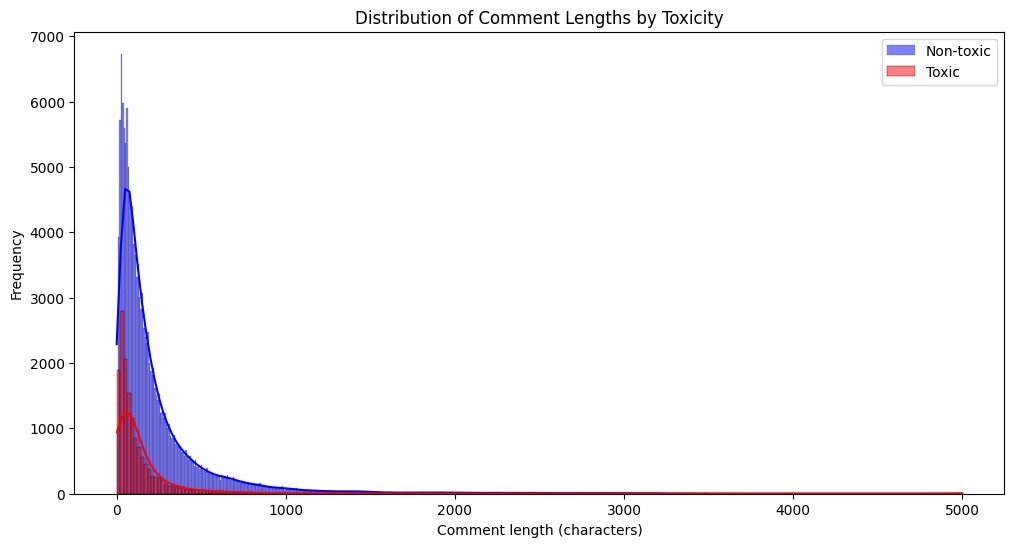

In [24]:
plt.figure(figsize=(12,6))

sns.histplot(df[df['toxic'] == 0]['comment_text'].str.len(),
             color='blue', label='Non-toxic', kde=True)

sns.histplot(df[df['toxic'] == 1]['comment_text'].str.len(),
             color='red', label='Toxic', kde=True)

plt.legend()
plt.xlabel("Comment length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Lengths by Toxicity")
plt.show()


In [25]:
# Convert text to padded sequences
test_padded = pad_sequences(tokenizer.texts_to_sequences(df_test['comment_text']),
                            maxlen=Max_len, padding="post")

# Add toxic column with binary predictions
df_test['toxic'] = (lstm_model.predict(test_padded) > 0.5).astype("int32")


4787/4787 ━━━━━━━━━━━━━━━━━━━━ 97s 20ms/step


In [26]:
df_test

,id,comment_text,toxic
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...,1
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...,1
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",0
3,00017563c3f7919a,":If you have a look back at the source, the in...",0
4,00017695ad8997eb,I don't anonymously edit articles at all.,0
...,...,...,...
153159,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu...",1
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...,0
153161,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ...",0
153162,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the...",0


In [33]:
import pickle

with open('lstm_model.pkl','wb') as f:
    pickle.dump(lstm_model,f)

In [ ]:
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load model and tokenizer
model = pickle.load(open('lstm_model.pkl', 'rb'))
tokenizer = pickle.load(open('tokenizer.pkl', 'rb'))  # must be the same tokenizer used in training

# Input text
text = "aww match background colour seemingly stuck thanks talk january utc"


# Convert to sequence
seq = tokenizer.texts_to_sequences([text])

# Pad to same length used in training
padded_seq = pad_sequences(seq, maxlen=100)  # replace 100 with the maxlen you used during training

# Predict
prediction = model.predict(padded_seq)
print("Prediction:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: [[0.49643344]]


In [62]:
Y_train_pred

array([[1],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(127656, 1), dtype=int32)

In [ ]:
###GRU

In [56]:
gru_model = Sequential([
    Embedding(Vocb_Size, 64, input_length=Max_len),
    GRU(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")   # binary output
])

gru_model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

gru_model.summary()

c:\Users\priya\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
gru_model.fit(X_train_pad, y_train,
              validation_data=(X_test_pad, y_test),
              epochs=5,
              batch_size=64)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 138s 69ms/step - accuracy: 0.9446 - loss: 0.1670 - val_accuracy: 0.9620 - val_loss: 0.1062
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 152s 76ms/step - accuracy: 0.9651 - loss: 0.0936 - val_accuracy: 0.9621 - val_loss: 0.1086
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 209s 105ms/step - accuracy: 0.9705 - loss: 0.0772 - val_accuracy: 0.9587 - val_loss: 0.1269
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 284s 116ms/step - accuracy: 0.9749 - loss: 0.0665 - val_accuracy: 0.9565 - val_loss: 0.1464
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1153s 563ms/step - accuracy: 0.9807 - loss: 0.0514 - val_accuracy: 0.9527 - val_loss: 0.1733


In [58]:
Y_train_pred = (gru_model.predict(X_train_pad, verbose=0) > 0.5).astype("int32")
Y_test_pred  = (gru_model.predict(X_test_pad, verbose=0) > 0.5).astype("int32")

print("Classification Report For Train Data")
print(classification_report(y_train, Y_train_pred, target_names=["Non-Toxic","Toxic"]))

print("Classification Report For Test Data")
print(classification_report(y_test, Y_test_pred, target_names=["Non-Toxic","Toxic"]))

Classification Report For Train Data
              precision    recall  f1-score   support

   Non-Toxic       0.99      0.99      0.99    115418
       Toxic       0.93      0.95      0.94     12238

    accuracy                           0.99    127656
   macro avg       0.96      0.97      0.97    127656
weighted avg       0.99      0.99      0.99    127656

Classification Report For Test Data
              precision    recall  f1-score   support

   Non-Toxic       0.97      0.97      0.97     28859
       Toxic       0.76      0.75      0.75      3056

    accuracy                           0.95     31915
   macro avg       0.86      0.86      0.86     31915
weighted avg       0.95      0.95      0.95     31915



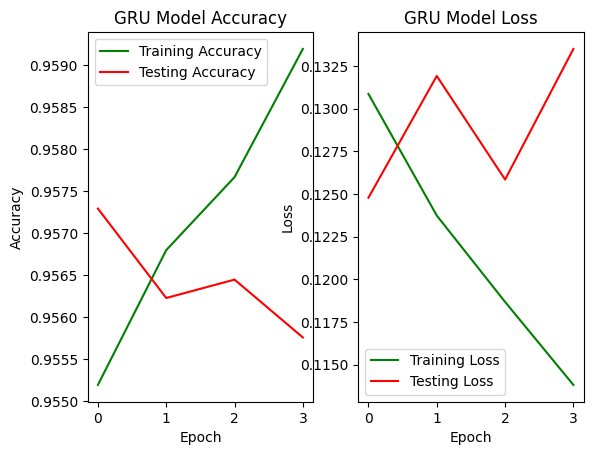

In [59]:
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], color='green', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='red', label='Testing Accuracy')
plt.legend()
plt.title('GRU Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], color='green', label='Training Loss')
plt.plot(history.history['val_loss'], color='red', label='Testing Loss')
plt.legend()
plt.title('GRU Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()